<a href="https://colab.research.google.com/github/JJJuniorDev/ML-colab/blob/main/CNN_computer_vision_plots_and_multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import zipfile
# Download zip file of pizza_steak images
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

--2026-03-08 19:29:11--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.195.207, 172.253.117.207, 173.194.202.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.195.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   180MB/s    in 0.6s    

2026-03-08 19:29:12 (180 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



In [3]:
import os
#unzip
zip_ref=zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

In [4]:
num_steak_images_train=len(os.listdir("pizza_steak/train/steak"))
num_steak_images_train

750

In [5]:
import pathlib
import numpy as np
data_dir=pathlib.Path("pizza_steak/train")
class_names=np.array(sorted([item.name for item in data_dir.glob("*")]))
print(class_names)

['pizza' 'steak']


In [6]:
import matplotlib.image as mpimg
import random
def view_random_image(target_dir, target_class):
  #target directory
  target_folder=target_dir+target_class
  #get a random image path
  random_image=random.sample(os.listdir(target_folder), 1)
  img=mpimg.imread(target_folder+"/"+random_image[0])
  plt.imshow(img) #mostra immagine
  plt.title(target_class) #pizza or steak
  plt.axis("off")
  print(f"Image shape: {img.shape}")
  return img

Image shape: (512, 512, 3)


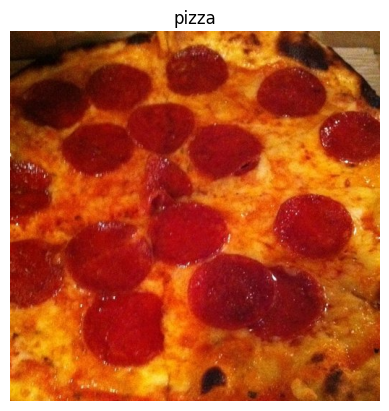

In [7]:
img= view_random_image(target_dir="pizza_steak/train/",
                       target_class="pizza")

In [8]:
tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 51,  20,   0],
        [ 58,  27,   7],
        [ 60,  32,  11],
        ...,
        [120,  76,  31],
        [119,  75,  28],
        [132,  88,  41]],

       [[ 52,  21,   1],
        [ 55,  24,   4],
        [ 53,  25,   4],
        ...,
        [117,  73,  28],
        [114,  70,  23],
        [119,  75,  28]],

       [[ 64,  33,  13],
        [ 62,  31,  11],
        [ 54,  26,   5],
        ...,
        [121,  77,  30],
        [120,  76,  29],
        [116,  72,  25]],

       ...,

       [[214, 126,   2],
        [221, 136,   9],
        [234, 146,  20],
        ...,
        [117,  44,   3],
        [131,  57,  18],
        [133,  59,  20]],

       [[201, 110,   0],
        [212, 123,   3],
        [227, 137,  15],
        ...,
        [110,  37,   0],
        [124,  52,  12],
        [125,  53,  15]],

       [[183,  92,   0],
        [196, 105,   0],
        [212, 121,   4],
        ...,
        [109,  36,   

In [9]:
img.shape #width, height, colour channels

(512, 512, 3)

creiamo una CNN per trovare patterns nelle immagini, dobbiamo:


*   Caricare le immagini
*   Pre processarle
*   Costruire la CNN
*   Compilare la CNN
*   Fittare la CNN



In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

#preprocessing (rendiamo i pixel tra 0 e 1 [scaling/normalizing])
train_datagen=ImageDataGenerator(rescale=1./255)
valid_datagen=ImageDataGenerator(rescale=1./255)

#set up paths per le directories
train_dir="/content/pizza_steak/train"
test_dir="pizza_steak/test"
#import dalle directories e trasformiamo in batches
train_data=train_datagen.flow_from_directory(directory=train_dir,
                                             batch_size=32,
                                             target_size=(224, 224),
                                             class_mode="binary",
                                             seed=42)
valid_data= valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                             target_size=(224, 224),
                                             class_mode="binary",
                                              seed=42)

#Costruzione CNN
model_CNN=tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation="relu",
                           input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding="valid"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

#Compiliamo la CNN
model_CNN.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(),
                   metrics=["accuracy"])
#flow_from_directory sopra crea dati e labels insieme in train_data
history_CNN=model_CNN.fit(train_data, epochs=5, steps_per_epoch=len(train_data),
                          validation_data=valid_data, validation_steps=len(valid_data))


Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 262ms/step - accuracy: 0.5548 - loss: 0.6742 - val_accuracy: 0.7940 - val_loss: 0.4491
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.7884 - loss: 0.4569 - val_accuracy: 0.8400 - val_loss: 0.3827
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.8074 - loss: 0.4206 - val_accuracy: 0.8620 - val_loss: 0.3595
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.8281 - loss: 0.3880 - val_accuracy: 0.8700 - val_loss: 0.3373
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.8499 - loss: 0.3365 - val_accuracy: 0.8860 - val_loss: 0.3098


In [11]:
model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

In [12]:
tf.random.set_seed(42)
#MODELLO DI NN come prima performa MOLTO MOLTO PEGGIO
model_2=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

#Compiliamo la CNN
model_2.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(),
                   metrics=["accuracy"])
#flow_from_directory sopra crea dati e labels insieme in train_data
history_2=model_2.fit(train_data, epochs=5, steps_per_epoch=len(train_data),
                          validation_data=valid_data, validation_steps=len(valid_data))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.5545 - loss: 12.3925 - val_accuracy: 0.7180 - val_loss: 1.9989
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.7225 - loss: 1.3554 - val_accuracy: 0.6620 - val_loss: 2.0311
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.6977 - loss: 1.5373 - val_accuracy: 0.6920 - val_loss: 1.2790
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.7377 - loss: 0.8913 - val_accuracy: 0.6340 - val_loss: 0.9466
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.7123 - loss: 0.8807 - val_accuracy: 0.7860 - val_loss: 0.4684


In [13]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,189,305 (172.38 MB)

 Trainable params: 15,063,101 (57.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,126,204 (114.92 MB)

Image shape: (512, 512, 3)
Image shape: (512, 512, 3)


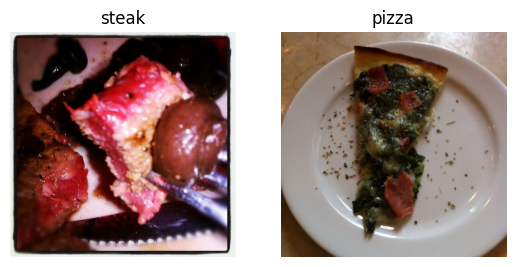

In [14]:
plt.figure()
plt.subplot(1,2,1)
steak_img=view_random_image("pizza_steak/train/", "steak")
plt.subplot(1,2,2)
pizza_img=view_random_image("pizza_steak/train/", "pizza")

DI NUOVO STEPS CON BATCH

In [15]:
train_dir="pizza_steak/train"
test_dir="pizza_steak/test"
#rendiamo in batch , di solito 32, troppe immagini tutte insieme non fittano in memoria (es. 1kkk)

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen=ImageDataGenerator(rescale=1/255.)
test_datagen=ImageDataGenerator(rescale=1/255.)

In [17]:
#carichiamo i dati delle immagini dalle directories e trasformiamoli in batch
train_data=train_datagen.flow_from_directory(directory=train_dir,
                                             target_size=(224,224),
                                             class_mode="binary",
                                             batch_size=32)
test_data=test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224,224),
                                             class_mode="binary",
                                             batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [18]:
#questo modello è la nostra baseline, da migliorare
model_CNN_2= tf.keras.Sequential([
   tf.keras.layers.Conv2D(filters=10, #n di filtri che passano sul layer, +=complessità modello
                           kernel_size=3, #quanto è grande un filtro, piccoli valori=impara piccole features e viceversa
                           strides=1, #filtro si muove sull'immagine 1 pixel alla volta
                           padding="valid",#con valid output shape compressa, same=
                           activation="relu",
                           input_shape=(224,224,3)), #input layer
   tf.keras.layers.Conv2D(10,3,activation="relu"),
   tf.keras.layers.Conv2D(10,3,activation="relu"),
   tf.keras.layers.Flatten(),
   tf.keras.layers.Dense(1, activation="sigmoid") #output layer
])

model_CNN_2.compile(loss="binary_crossentropy",
                    optimizer=tf.keras.optimizers.Adam(),
                    metrics=["accuracy"])

In [19]:
model_CNN_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,341 (1.82 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#steps per epochs è il numero di batches che deve fare prima di passare alla prox epoca
history_2=model_CNN_2.fit(train_data, epochs=5, steps_per_epoch=len(train_data),
                    validation_data=test_data, validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 190ms/step - accuracy: 0.6162 - loss: 2.8180 - val_accuracy: 0.8000 - val_loss: 0.4368
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.8005 - loss: 0.4381 - val_accuracy: 0.8040 - val_loss: 0.4383
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.8403 - loss: 0.3663 - val_accuracy: 0.8180 - val_loss: 0.3948
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.9366 - loss: 0.2025 - val_accuracy: 0.7180 - val_loss: 0.6071
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.9573 - loss: 0.1417 - val_accuracy: 0.7760 - val_loss: 0.5590


<Axes: >

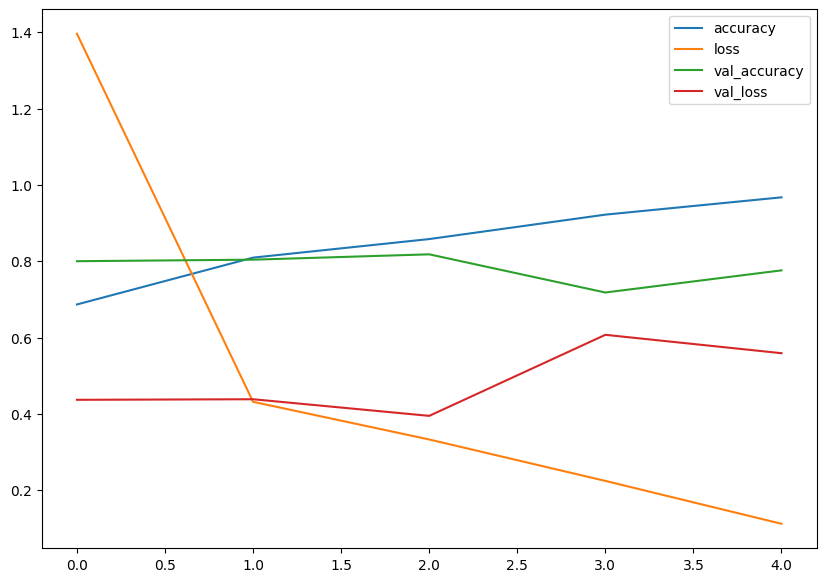

In [21]:
pd.DataFrame(history_2.history).plot(figsize=(10,7))

In [22]:
model_CNN_3_improved= tf.keras.Sequential([
   tf.keras.layers.Conv2D(filters=10, #n di filtri che passano sul layer, +=complessità modello
                           kernel_size=3, #quanto è grande un filtro, piccoli valori=impara piccole features e viceversa
                           strides=1, #filtro si muove sull'immagine 1 pixel alla volta
                           padding="valid",#con valid output shape compressa, same=
                           activation="relu",
                           input_shape=(224,224,3)), #input layer
   tf.keras.layers.MaxPool2D(pool_size=2), #trova le parti piu importanti delle feature e le condensa
   tf.keras.layers.Conv2D(10,3,activation="relu"),
   tf.keras.layers.MaxPool2D(),
   tf.keras.layers.Conv2D(10,3,activation="relu"),
   tf.keras.layers.MaxPool2D(),
   tf.keras.layers.Flatten(),
   tf.keras.layers.Dense(1, activation="sigmoid") #output layer
])


model_CNN_3_improved.compile(loss="binary_crossentropy",
                    optimizer=tf.keras.optimizers.Adam(),
                    metrics=["accuracy"])

history_3=model_CNN_3_improved.fit(train_data, epochs=5, steps_per_epoch=len(train_data),
                    validation_data=test_data, validation_steps=len(test_data))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.6086 - loss: 0.6397 - val_accuracy: 0.8060 - val_loss: 0.4631
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7597 - loss: 0.5114 - val_accuracy: 0.8360 - val_loss: 0.3987
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.7919 - loss: 0.4733 - val_accuracy: 0.8300 - val_loss: 0.3847
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.8272 - loss: 0.4106 - val_accuracy: 0.8420 - val_loss: 0.3728
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.8291 - loss: 0.4215 - val_accuracy: 0.8040 - val_loss: 0.4091


In [23]:
model_CNN_3_improved.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         6,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,585 (103.85 KB)

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

<Axes: >

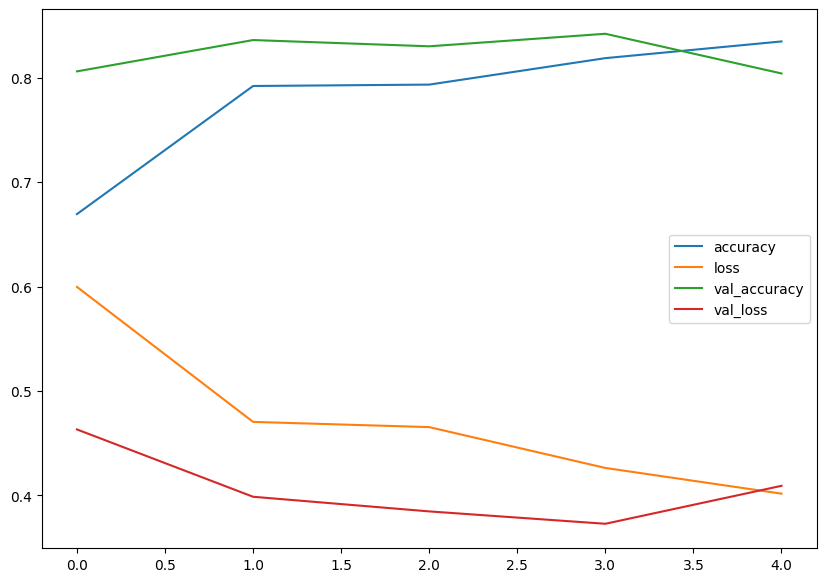

In [24]:
pd.DataFrame(history_3.history).plot(figsize=(10,7))

DATA AUGMENTATION per ridurre overfitting
⛽ cos'è? == alterare training data dandogli più diversità e imparare patterns più generalizzabili.
Es. cambiare la rotazione immagine, flipparla, tagliarla...

In [25]:
#ImageDataGenerator con data augmentation
train_datagen_augmented=ImageDataGenerator(rescale=1/255.,
                                           rotation_range=0.2, #quanto rotiamo
                                           shear_range=0.2, #taglio, inclinata obliquamente
                                           zoom_range=0.2,
                                           width_shift_range=0.2,
                                           height_shift_range=0.3,
                                           horizontal_flip=True)
#vediamo la differenza senza
test_datagen=ImageDataGenerator(rescale=1/255.)

In [26]:
print("Augmented training data")
train_datagen_augmented=train_datagen_augmented.flow_from_directory(train_dir,
                                            target_size=(224,224),
                                            batch_size=32,
                                            class_mode="binary",
                                            )
#batches non augmented
print("NON Augmented training data")
train_data=train_datagen.flow_from_directory(train_dir,
                                             target_size=(224,224),
                                            batch_size=32,
                                            class_mode="binary",
                                            )
print("NON Augmented test data:")
test_data=test_datagen.flow_from_directory(test_dir,
                                           target_size=(224,224),
                                           batch_size=32,
                                           class_mode="binary")

Augmented training data
Found 1500 images belonging to 2 classes.
NON Augmented training data
Found 1500 images belonging to 2 classes.
NON Augmented test data:
Found 500 images belonging to 2 classes.


⚓ Data Augmentation è fatta di solito solo su training data. GLi rendiamo difficile imparare sul training data cosi generalizza meglio sul test data

In [27]:
images, labels = next(train_data)
augmented_images, augmented_labels=next(train_datagen_augmented)

immagine numero: 7


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

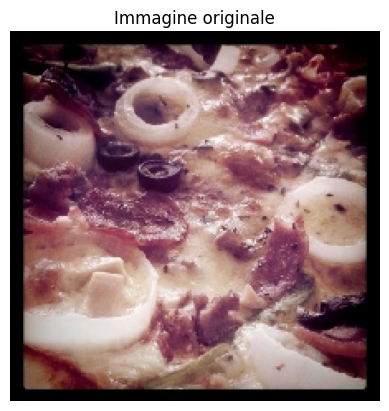

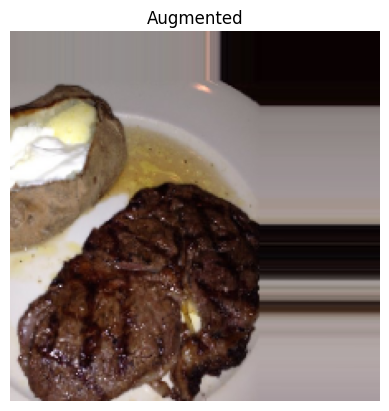

In [28]:
import random
random_number=random.randint(0,32) #abbiamo 32 immagini nel batch
print(f"immagine numero: {random_number}")
plt.imshow(images[random_number])
plt.title(f"Immagine originale")
plt.axis(False)


plt.figure()
plt.imshow(augmented_images[random_number])
plt.title("Augmented")
plt.axis(False)

In [29]:
model_4_data_augmentation=tf.keras.Sequential([
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_4_data_augmentation.compile(loss="binary_crossentropy",
                                  optimizer=tf.keras.optimizers.Adam(),
                                  metrics=["accuracy"])

history_4=model_4_data_augmentation.fit(train_datagen_augmented,
                                    epochs=5,
                                    steps_per_epoch=len(train_datagen_augmented),
                                    validation_data=test_data,
                                    validation_steps=len(test_data))



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 451ms/step - accuracy: 0.5088 - loss: 0.6957 - val_accuracy: 0.6220 - val_loss: 0.6163
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 405ms/step - accuracy: 0.6135 - loss: 0.6439 - val_accuracy: 0.8180 - val_loss: 0.4622
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 426ms/step - accuracy: 0.7078 - loss: 0.5559 - val_accuracy: 0.8440 - val_loss: 0.3867
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 402ms/step - accuracy: 0.7269 - loss: 0.5308 - val_accuracy: 0.8220 - val_loss: 0.3791
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 426ms/step - accuracy: 0.7610 - loss: 0.4934 - val_accuracy: 0.8580 - val_loss: 0.3409


<Axes: >

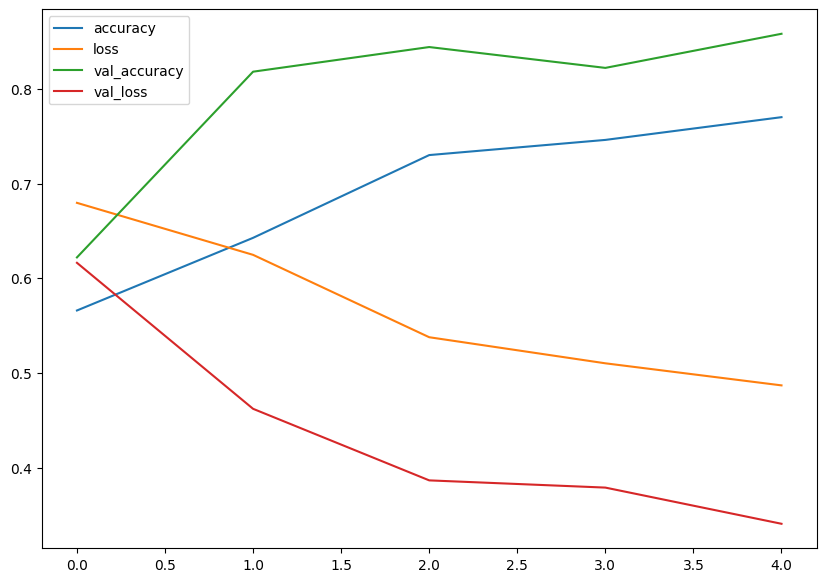

In [30]:
pd.DataFrame(history_4.history).plot(figsize=(10,7))

METODI PER MIGLIORARE:
-aumenta n layers (conv2d/MaxPool2D)
-aumenta n filtri in ogni convolutional layer (da 10 a 32-64)
-train piu a lungo
-trova lr ideale
prendi piu dati
-transfer learning di un altro image model e aggiusta


In [31]:
#Multiclass image classification
import zipfile
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

--2026-03-08 19:33:21--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.107.207, 192.178.163.207, 74.125.20.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.107.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  74.8MB/s    in 7.8s    

2026-03-08 19:33:29 (63.3 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [32]:
#unzip
zip_ref=zipfile.ZipFile("10_food_classes_all_data.zip", "r")
zip_ref.extractall()
zip_ref.close()

In [33]:
import os
for dirpath,dirnames, filenames in os.walk("10_food_classes_all_data"):
 print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

There are 2 directories and 0 images in '10_food_classes_all_data'
There are 10 directories and 0 images in '10_food_classes_all_data/train'
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_wings'
There are 0 directories and 750 images in '10_food_classes_all_data/train/hamburger'
There are 0 directories and 750 images in '10_food_classes_all_data/train/grilled_salmon'
There are 0 directories and 750 images in '10_food_classes_all_data/train/sushi'
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_curry'
There are 0 directories and 750 images in '10_food_classes_all_data/train/steak'
There are 0 directories and 750 images in '10_food_classes_all_data/train/ice_cream'
There are 0 directories and 750 images in '10_food_classes_all_data/train/ramen'
There are 0 directories and 750 images in '10_food_classes_all_data/train/fried_rice'
There are 0 directories and 750 images in '10_food_classes_all_data/train/pizza'
There are 1

In [34]:
#test e train directories
train_dir="10_food_classes_all_data/train/"
test_dir="10_food_classes_all_data/test/"

In [35]:
#prendiamo i nomi delle classi
import pathlib
import numpy as np
data_dir=pathlib.Path(train_dir)
class_names=np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


Image shape: (512, 512, 3)


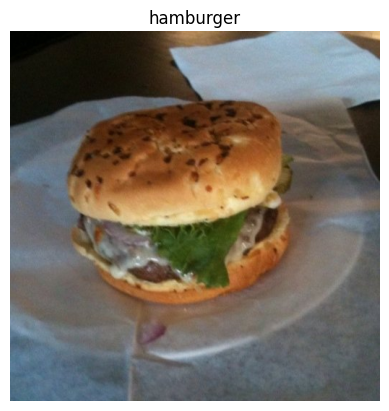

In [36]:
import random
img =view_random_image(target_dir=train_dir,
                       target_class=random.choice(class_names))

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#rescale
train_datagen=ImageDataGenerator(rescale=1/255.)
test_datagen=ImageDataGenerator(rescale=1/255.)
#carichiamo dati da directory e trasformiamo in batches
train_data=train_datagen.flow_from_directory(train_dir,
                                             target_size=(224,224),
                                             batch_size=32,
                                             class_mode='categorical',
                                             )
test_data=test_datagen.flow_from_directory(test_dir,
                                           target_size=(224,224),
                                           batch_size=32,
                                           class_mode='categorical')

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [38]:
#creiamo model baseline

model_multiclass=tf.keras.Sequential([
    tf.keras.layers.Conv2D(10, 3, input_shape=(224,224,3), activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation="softmax")
])

model_multiclass.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                         optimizer=tf.keras.optimizers.Adam(),
                         metrics=["accuracy"])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
history_multiclass=model_multiclass.fit(train_data,
                                        epochs=5,
                                        steps_per_epoch=len(train_data),
                                        validation_data=test_data,
                                        validation_steps=int(0.25 * len(test_data)))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.1562 - loss: 2.2423 - val_accuracy: 0.2796 - val_loss: 1.9910
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.3237 - loss: 1.9156 - val_accuracy: 0.3076 - val_loss: 1.9092
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.4087 - loss: 1.7064 - val_accuracy: 0.3454 - val_loss: 1.8358
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.5771 - loss: 1.3040 - val_accuracy: 0.3372 - val_loss: 2.0323
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.7760 - loss: 0.7511 - val_accuracy: 0.3257 - val_loss: 2.3292


<Axes: >

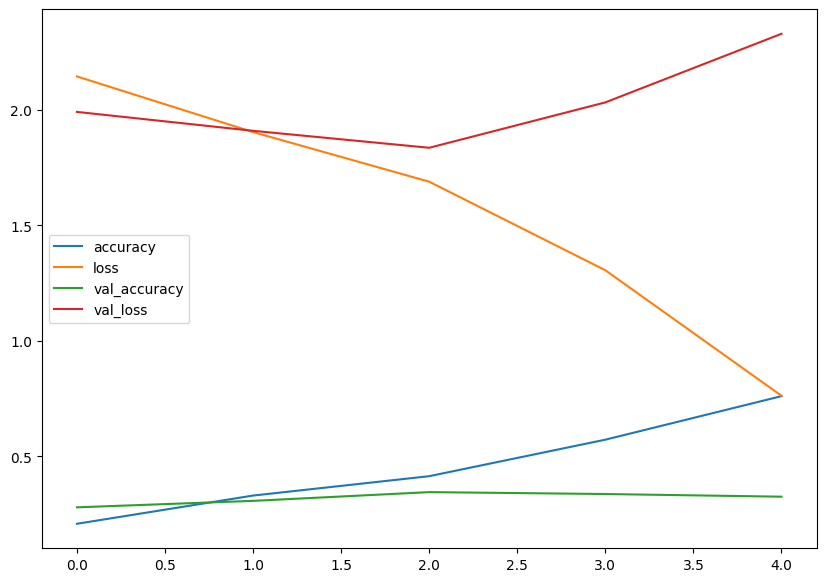

In [40]:
pd.DataFrame(history_multiclass.history).plot(figsize=(10,7))